In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Read in Data

In [2]:
eda_df = pd.read_csv('eda_data.csv')

In [3]:
model_df = pd.read_csv('model_data.csv')

# Overview of Data

In [6]:
eda_df.shape

(7043, 20)

# Overall Distribution of Churn

/var/folders/st/218s55451fg4sfvmvvt7rz780000gn/T/ipykernel_61568/2542101431.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=eda_df, x='Churn', palette=['#FF6B00', '#4DA6FF'],alpha = 0.8)
/var/folders/st/218s55451fg4sfvmvvt7rz780000gn/T/ipykernel_61568/2542101431.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i, v + 50, f'{v}\n({churn_counts[i]/len(eda_df)*100:.1f}%)',


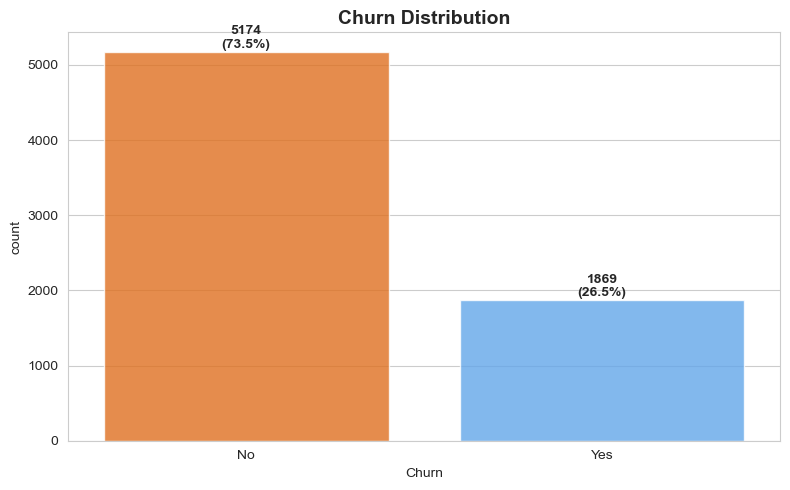

In [40]:
plt.figure(figsize=(8, 5))
churn_counts = eda_df['Churn'].value_counts()
sns.countplot(data=eda_df, x='Churn', palette=['#FF6B00', '#4DA6FF'],alpha = 0.8)
plt.title('Churn Distribution', fontsize=14, fontweight='bold')
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 50, f'{v}\n({churn_counts[i]/len(eda_df)*100:.1f}%)', 
             ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=450, bbox_inches='tight')
plt.show()

# Summary Statistics for all Features

In [42]:
# Get only categorical columns (object dtype)
cat_cols = eda_df.select_dtypes(include=['object']).columns.tolist()

# Remove Churn if it's in the list
if 'Churn' in cat_cols:
    cat_cols.remove('Churn')

# Create summary table
summary_data = []

for col in cat_cols:
    value_counts = eda_df[col].value_counts()
    total = len(eda_df)
    
    # Get top categories
    for category, count in value_counts.items():
        percentage = (count / total) * 100
        summary_data.append({
            'Feature': col,
            'Category': category,
            'Count': count,
            'Percentage': f'{percentage:.1f}%'
        })
    
    # Add a separator row for readability
    summary_data.append({
        'Feature': '---',
        'Category': '---',
        'Count': '---',
        'Percentage': '---'
    })

# Create DataFrame
cat_dist_table = pd.DataFrame(summary_data)

# Display table
print(cat_dist_table.to_string(index=False))

         Feature                  Category Count Percentage
          gender                      Male  3555      50.5%
          gender                    Female  3488      49.5%
             ---                       ---   ---        ---
   SeniorCitizen                        No  5901      83.8%
   SeniorCitizen                       Yes  1142      16.2%
             ---                       ---   ---        ---
         Partner                        No  3641      51.7%
         Partner                       Yes  3402      48.3%
             ---                       ---   ---        ---
      Dependents                        No  4933      70.0%
      Dependents                       Yes  2110      30.0%
             ---                       ---   ---        ---
    PhoneService                       Yes  6361      90.3%
    PhoneService                        No   682       9.7%
             ---                       ---   ---        ---
   MultipleLines                        

## Numeric Features

In [63]:
# Get numeric columns from eda_df
num_cols = eda_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'Churn' in num_cols:
    num_cols.remove('Churn')

# Numeric Features Distribution Summary
distribution_data = []

for col in num_cols:
    data = eda_df[col]
    
    # Basic statistics
    mean_val = data.mean()
    median_val = data.median()
    std_val = data.std()
    min_val = data.min()
    max_val = data.max()
    q25 = data.quantile(0.25)
    q75 = data.quantile(0.75)
    iqr = q75 - q25
    
    # Skewness
    skew = data.skew()
    
    # Outliers
    outliers = data[(data < q25 - 1.5*iqr) | (data > q75 + 1.5*iqr)].count()
    outlier_pct = (outliers / len(data)) * 100
    
    # Churn comparison (if Churn exists as string)
    if 'Churn' in eda_df.columns and eda_df['Churn'].dtype == 'object':
        churn_yes = eda_df[eda_df['Churn'] == 'Yes'][col]
        churn_no = eda_df[eda_df['Churn'] == 'No'][col]
        
        # T-test
        t_stat, p_val = stats.ttest_ind(churn_yes, churn_no)
        
        # Significance indicator
        if p_val < 0.001:
            sig = '***'
        elif p_val < 0.01:
            sig = '**'
        elif p_val < 0.05:
            sig = '*'
        else:
            sig = 'ns'
    else:
        churn_yes_mean = 'N/A'
        churn_no_mean = 'N/A'
        p_val = 'N/A'
        sig = ''
    
    distribution_data.append({
        'Feature': col,
        'Mean': f'{mean_val:.2f}',
        'Median': f'{median_val:.2f}',
        'Std Dev': f'{std_val:.2f}',
        'Min': f'{min_val:.2f}',
        'Max': f'{max_val:.2f}',
        'Q1': f'{q25:.2f}',
        'Q3': f'{q75:.2f}',
        'IQR': f'{iqr:.2f}',
        'Skew': f'{skew:.2f}',
        'Outliers': f'{outliers} ({outlier_pct:.1f}%)',
        'Churn Mean': f'{churn_yes.mean():.2f}' if churn_yes is not None else 'N/A',
        'No Churn Mean': f'{churn_no.mean():.2f}' if churn_no is not None else 'N/A',
        'P-Value': f'{p_val:.4f}{sig}' if p_val != 'N/A' else 'N/A'
    })

num_table = pd.DataFrame(distribution_data)

print("=" * 120)
print("NUMERIC FEATURES DISTRIBUTION SUMMARY")
print("=" * 120)
print(num_table.to_string(index=False))

# Save table
num_table.to_excel('numeric_distribution_table.xlsx', index=False)

NUMERIC FEATURES DISTRIBUTION SUMMARY
       Feature    Mean  Median Std Dev   Min     Max     Q1      Q3     IQR  Skew Outliers Churn Mean No Churn Mean   P-Value
        tenure   32.37   29.00   24.56  0.00   72.00   9.00   55.00   46.00  0.24 0 (0.0%)      17.98         37.57 0.0000***
MonthlyCharges   64.76   70.35   30.09 18.25  118.75  35.50   89.85   54.35 -0.22 0 (0.0%)      74.44         61.27 0.0000***
  TotalCharges 2279.73 1394.55 2266.79  0.00 8684.80 398.55 3786.60 3388.05  0.96 0 (0.0%)    1531.80       2549.91 0.0000***


/var/folders/st/218s55451fg4sfvmvvt7rz780000gn/T/ipykernel_61568/707301228.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x='Churn', y=col, ax=ax,
/var/folders/st/218s55451fg4sfvmvvt7rz780000gn/T/ipykernel_61568/707301228.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x='Churn', y=col, ax=ax,
/var/folders/st/218s55451fg4sfvmvvt7rz780000gn/T/ipykernel_61568/707301228.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x='Churn', y=col, ax=ax,


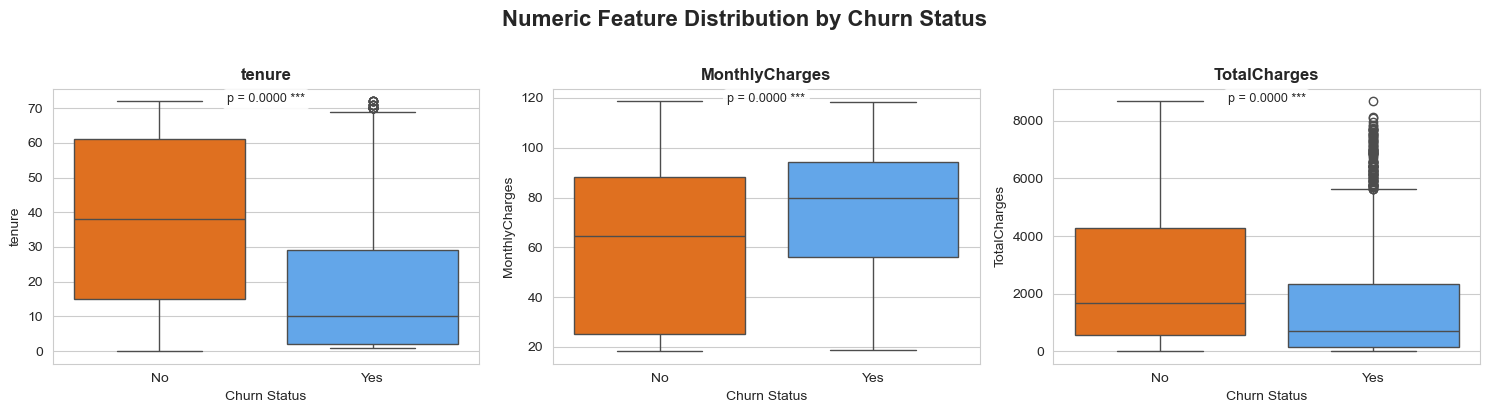

In [62]:
# FIGURE: Parallel Boxplot for All Numeric Features by Churn

# Reshape data for faceted boxplots
num_cols_for_plot = num_cols.copy()

# Create figure with subplots
n_cols = 3
n_rows = (len(num_cols_for_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols_for_plot):
    if i < len(axes):
        ax = axes[i]
        
        # Create boxplot
        sns.boxplot(data=eda_df, x='Churn', y=col, ax=ax, 
                   palette=['#FF6B00', '#4DA6FF'])
        
        # Add title
        ax.set_title(f'{col}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Churn Status')
        
        # Add statistical annotation
        if 'Churn' in eda_df.columns and eda_df['Churn'].dtype == 'object':
            churn_yes = eda_df[eda_df['Churn'] == 'Yes'][col]
            churn_no = eda_df[eda_df['Churn'] == 'No'][col]
            t_stat, p_val = stats.ttest_ind(churn_yes, churn_no)
            
            if p_val < 0.001:
                sig_text = '***'
            elif p_val < 0.01:
                sig_text = '**'
            elif p_val < 0.05:
                sig_text = '*'
            else:
                sig_text = 'ns'
            
            # Add significance annotation
            ax.text(0.5, 0.95, f'p = {p_val:.4f} {sig_text}', 
                   transform=ax.transAxes, ha='center', fontsize=9,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Remove empty subplots
for i in range(len(num_cols_for_plot), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Numeric Feature Distribution by Churn Status', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('numeric_boxplots_by_churn.png', dpi=450, bbox_inches='tight')
plt.show()

# Categorical Data by Churn Status

In [56]:
# Get categorical columns from eda_df
cat_cols = eda_df.select_dtypes(include=['object']).columns.tolist()
if 'Churn' in cat_cols:
    cat_cols.remove('Churn')

# Categorical Features Distribution Summary
cat_summary_data = []

for col in cat_cols:
    value_counts = eda_df[col].value_counts()
    total = len(eda_df)
    
    # Calculate churn rates
    churn_by_cat = eda_df.groupby(col)['Churn'].value_counts(normalize=True).unstack()
    churn_rate = churn_by_cat.get('Yes', 0) * 100
    
    # Get top 3 categories
    top_categories = []
    for cat, count in value_counts.head(3).items():
        pct = (count / total) * 100
        churn = churn_rate.get(cat, 0)
        top_categories.append(f"{cat} ({count}, {pct:.1f}%, churn: {churn:.1f}%)")
    
    # Get category with highest and lowest churn
    max_churn_cat = churn_rate.idxmax() if len(churn_rate) > 0 else 'N/A'
    max_churn_rate = churn_rate.max() if len(churn_rate) > 0 else 0
    min_churn_cat = churn_rate.idxmin() if len(churn_rate) > 0 else 'N/A'
    min_churn_rate = churn_rate.min() if len(churn_rate) > 0 else 0
    
    # Chi-square test
    contingency = pd.crosstab(eda_df[col], eda_df['Churn'])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
    
    if p_val < 0.001:
        sig = '***'
    elif p_val < 0.01:
        sig = '**'
    elif p_val < 0.05:
        sig = '*'
    else:
        sig = 'ns'
    
    cat_summary_data.append({
        'Feature': col,
        'Unique Values': len(value_counts),
        'Most Common': top_categories[0] if len(top_categories) > 0 else '',
        '2nd Most Common': top_categories[1] if len(top_categories) > 1 else '',
        '3rd Most Common': top_categories[2] if len(top_categories) > 2 else '',
        'Highest Churn': f'{max_churn_cat} ({max_churn_rate:.1f}%)',
        'Lowest Churn': f'{min_churn_cat} ({min_churn_rate:.1f}%)',
        'Chi-Square p-val': f'{p_val:.4f}{sig}'
    })

cat_table = pd.DataFrame(cat_summary_data)

print("=" * 120)
print("CATEGORICAL FEATURES SUMMARY")
print("=" * 120)
print(cat_table.to_string(index=False))

# Save table
cat_table.to_excel('categorical_distribution_table.xlsx', index=False)

CATEGORICAL FEATURES SUMMARY
         Feature  Unique Values                                  Most Common                          2nd Most Common                                       3rd Most Common            Highest Churn                    Lowest Churn Chi-Square p-val
          gender              2             Male (3555, 50.5%, churn: 26.2%)       Female (3488, 49.5%, churn: 26.9%)                                                                 Female (26.9%)                    Male (26.2%)         0.4866ns
   SeniorCitizen              2               No (5901, 83.8%, churn: 23.6%)          Yes (1142, 16.2%, churn: 41.7%)                                                                    Yes (41.7%)                      No (23.6%)        0.0000***
         Partner              2               No (3641, 51.7%, churn: 33.0%)          Yes (3402, 48.3%, churn: 19.7%)                                                                     No (33.0%)                     Yes (19.7%)     

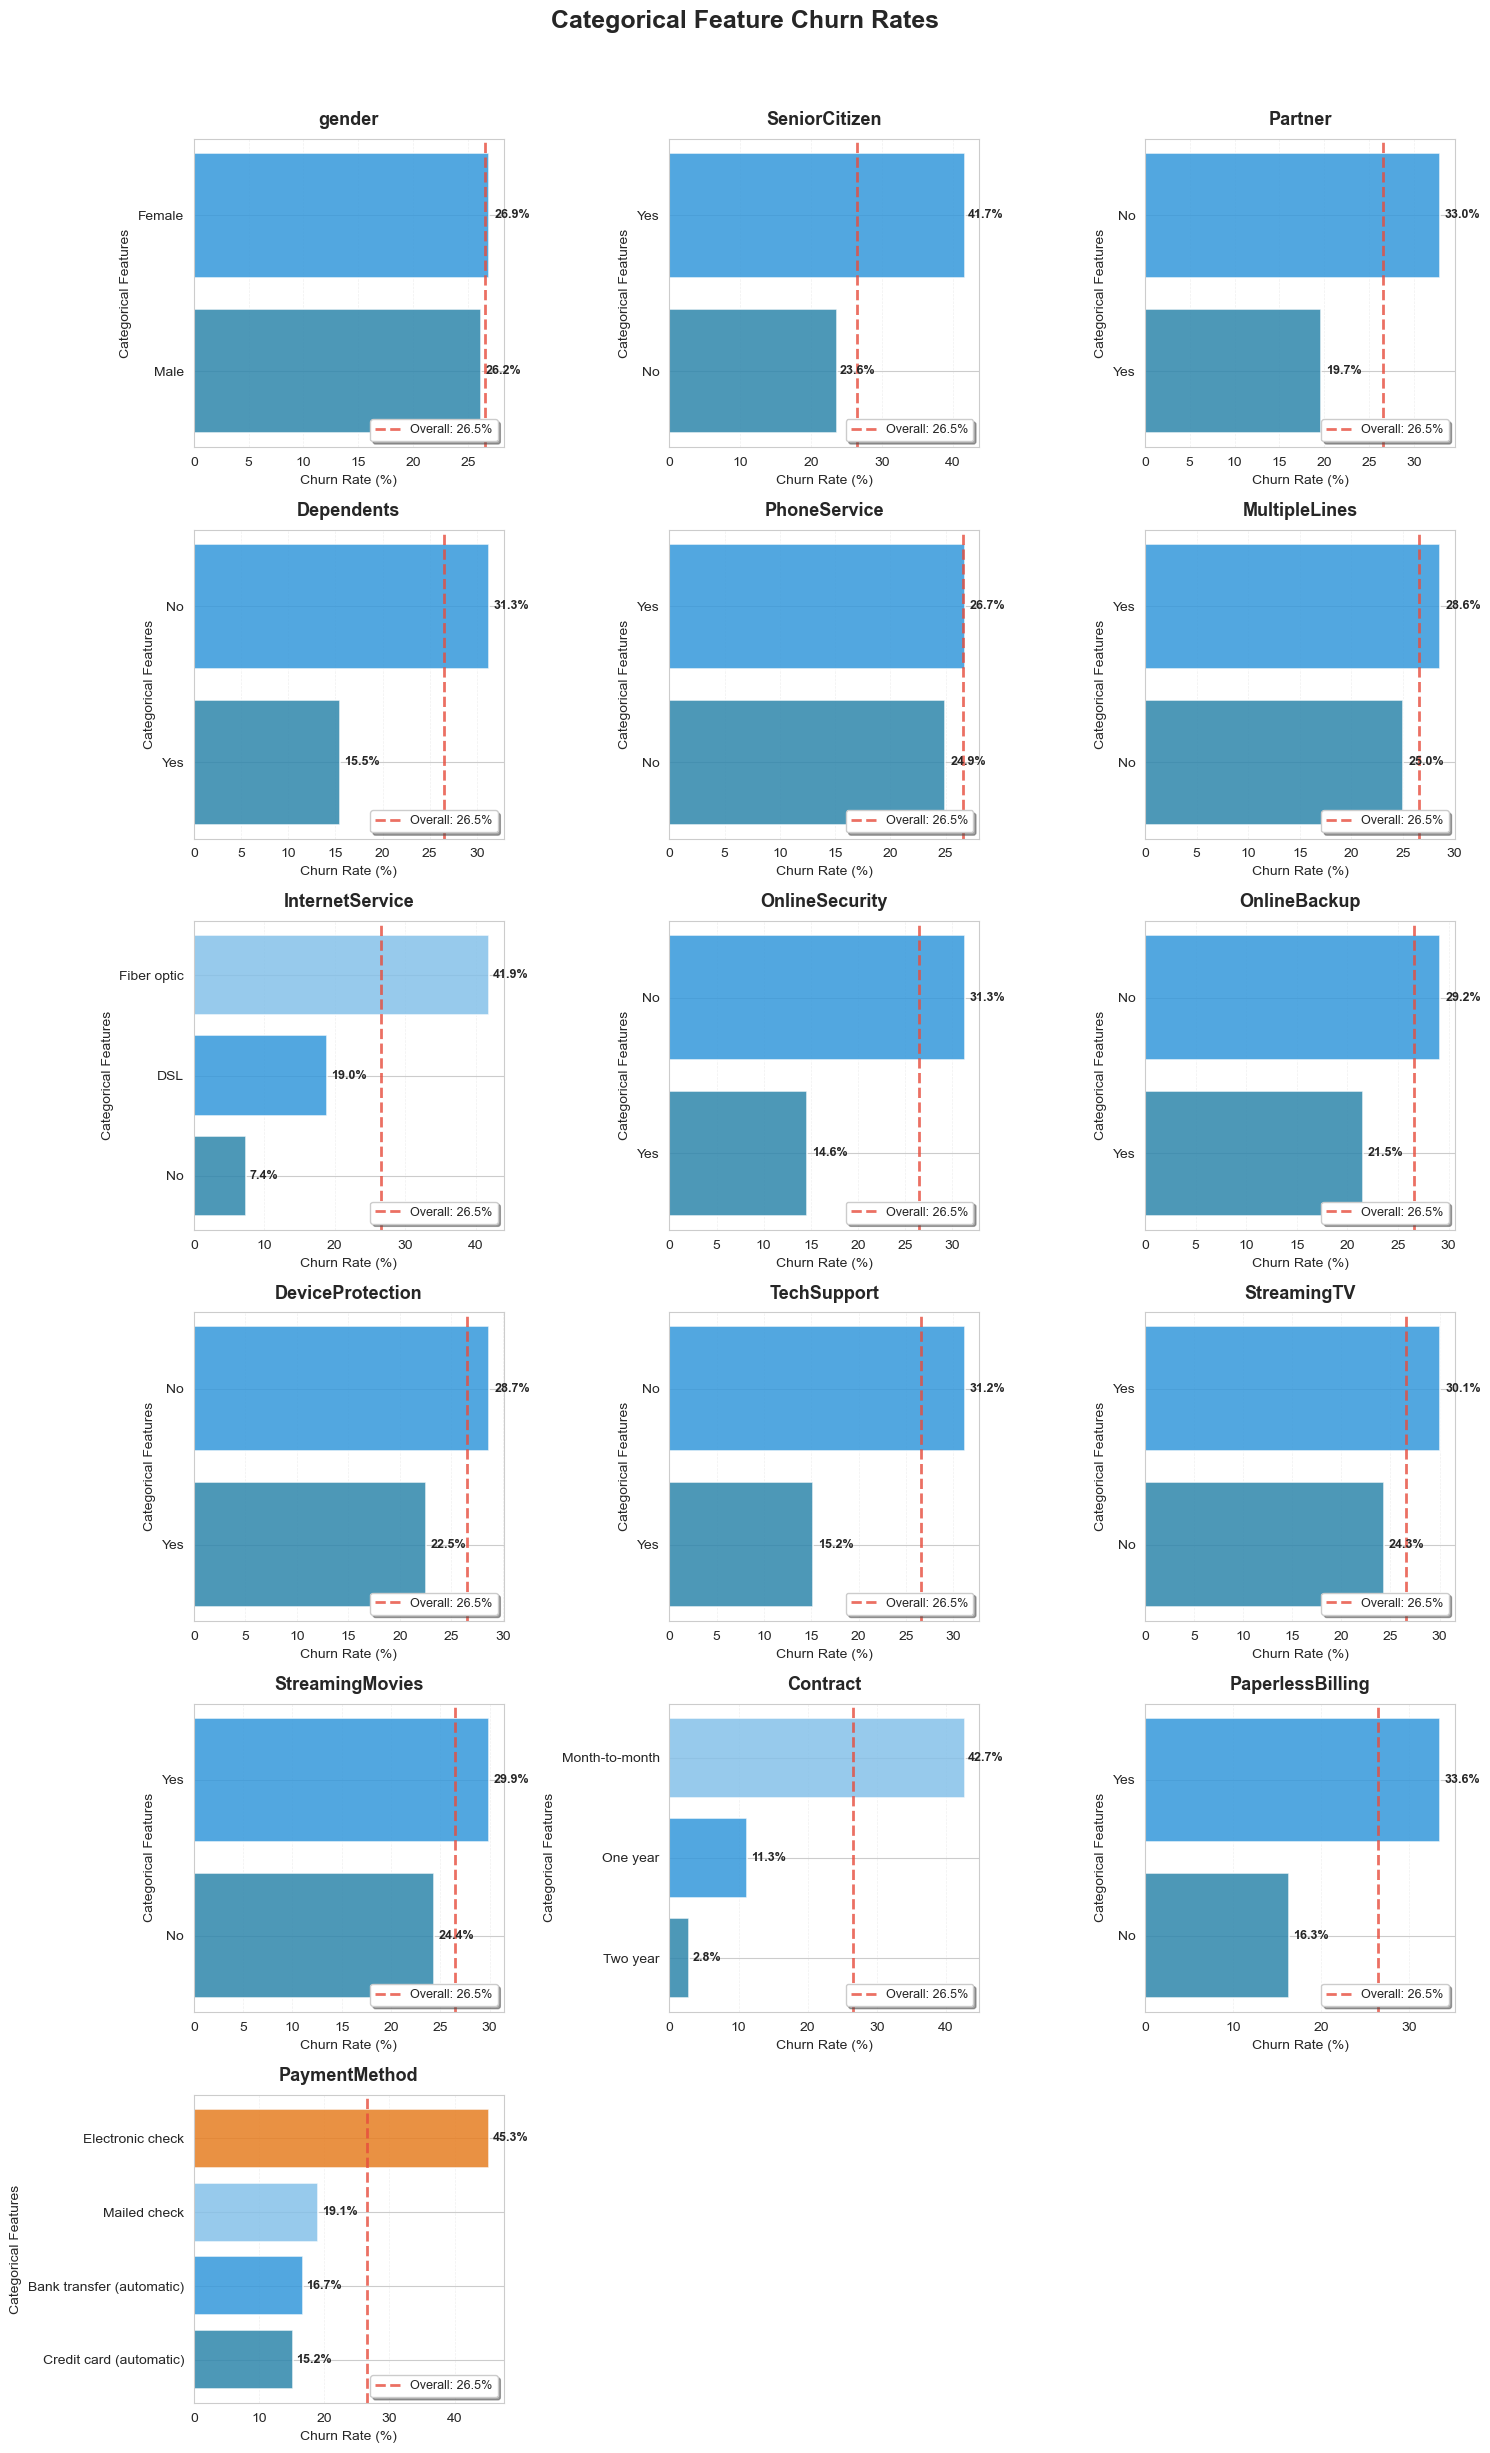

In [58]:
# Parallel Bar Charts

# Palette
color_p = ['#2E86AB', '#3498DB', '#85C1E9', '#E67E22', '#F39C12']

selected_palette = color_p

# Create subplots for categorical features
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if i < len(axes):
        ax = axes[i]
        
        # Calculate churn rate by category
        churn_by_cat = eda_df.groupby(col)['Churn'].value_counts(normalize=True).unstack()
        churn_rate = churn_by_cat.get('Yes', 0) * 100
        
        # Sort by churn rate
        churn_rate = churn_rate.sort_values()
        
        # Create color mapping based on number of categories
        n_categories = len(churn_rate)
        
        # If more categories than palette colors, cycle through
        if n_categories <= len(selected_palette):
            colors = selected_palette[:n_categories]
        else:
            # Create a color gradient
            colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.9, n_categories))
        
        # Create horizontal bar chart with colors
        bars = ax.barh(churn_rate.index, churn_rate.values, 
                       color=colors, 
                       edgecolor='white', 
                       linewidth=1.2, 
                       alpha=0.85)
        
        # Add overall churn rate line
        overall_churn = eda_df['Churn'].value_counts(normalize=True)['Yes'] * 100
        ax.axvline(overall_churn, color='#E74C3C', linestyle='--', linewidth=2, 
                   alpha=0.8, label=f'Overall: {overall_churn:.1f}%')
        
        # Add value labels
        for bar, rate in zip(bars, churn_rate.values):
            ax.text(rate + 0.5, bar.get_y() + bar.get_height()/2, 
                   f'{rate:.1f}%', va='center', fontsize=9, fontweight='bold')
        
        # Customize appearance
        ax.set_title(f'{col}', fontsize=13, fontweight='bold', pad=10)
        ax.set_xlabel('Churn Rate (%)', fontsize=10)
        ax.set_ylabel('Categorical Features')
        ax.legend(loc='lower right', fontsize=9, frameon=True, fancybox=True, shadow=True)
        
        # Add subtle grid
        ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
        ax.set_axisbelow(True)

# Remove empty subplots
for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Categorical Feature Churn Rates', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('categorical_churn_rates.png', dpi=450, bbox_inches='tight', facecolor='white')
plt.show()

## Heatmap Exploring Correlation with Churn

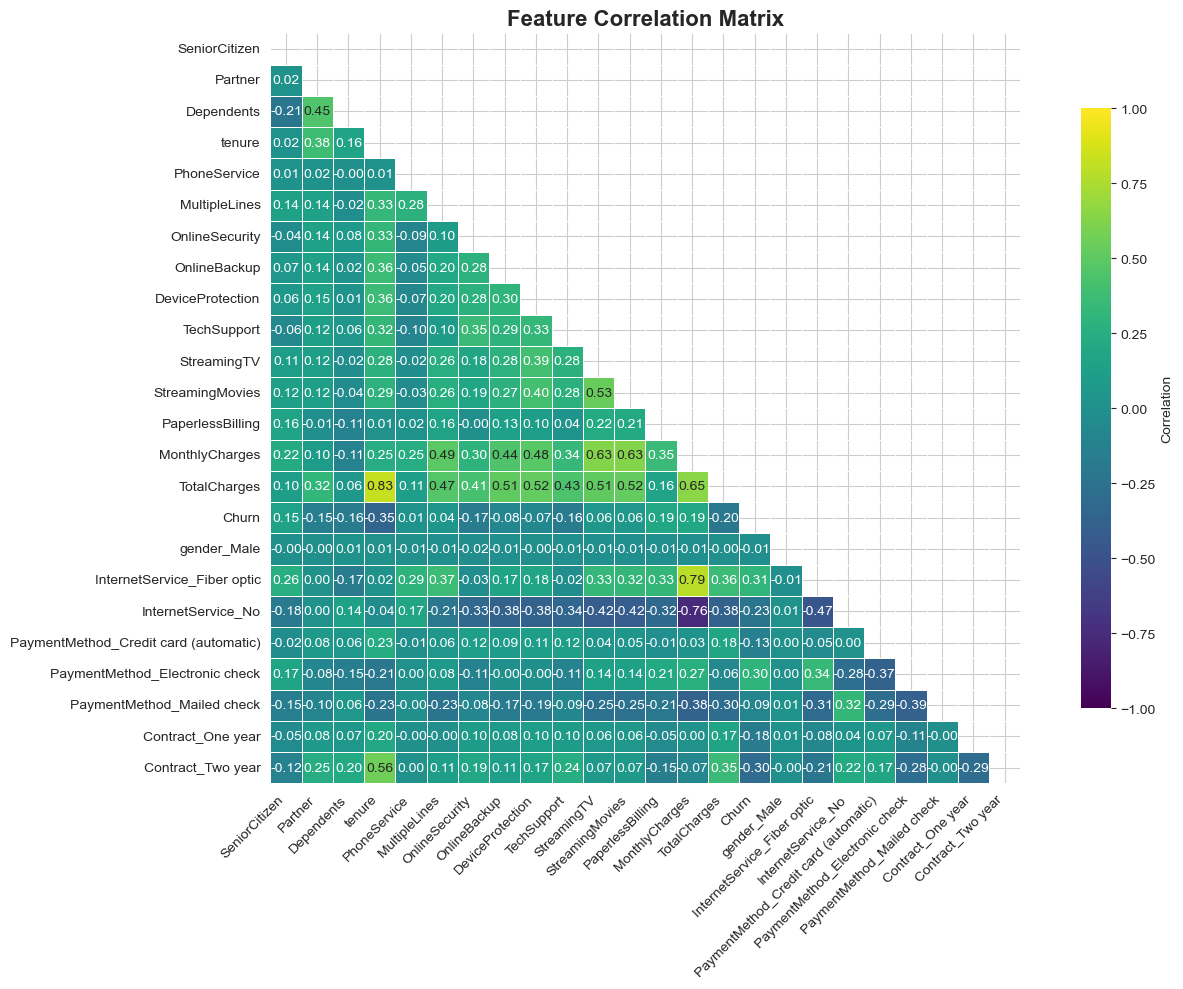

In [67]:
# Calculate correlation matrix
corr_matrix = model_df.corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Create heatmap with lower triangle only
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix,
            mask=mask, # Hides upper triangle
            annot=True,
            fmt='.2f',
            cmap='viridis', 
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlation"})

plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlation_heatmap_lower.png', dpi=450, bbox_inches='tight')
plt.show()

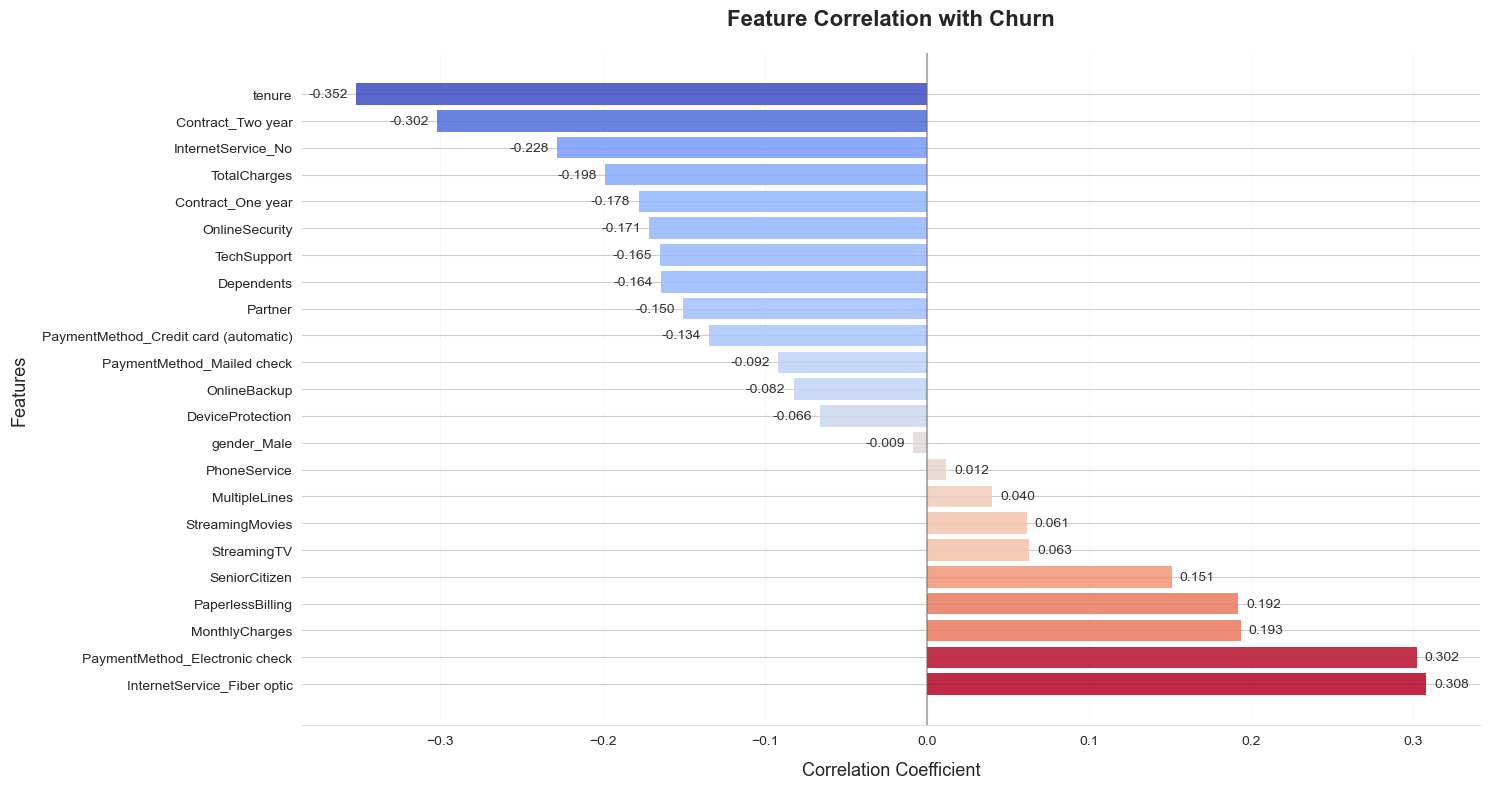

In [31]:
# Get correlations with Churn and sort
churn_corr = model_df.corr()['Churn'].drop('Churn').sort_values(ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(15, 8))

# Use a custom color gradient
norm = plt.Normalize(churn_corr.min(), churn_corr.max())
colors = plt.cm.coolwarm(norm(churn_corr.values))

bars = ax.barh(churn_corr.index, churn_corr.values, color=colors, 
               edgecolor='none', alpha=0.85)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#DDDDDD')

# Customize grid
ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)  # Grid behind bars

# Labels and title
ax.axvline(0, color='#666666', linestyle='-', linewidth=1.5, alpha=0.5)
ax.set_xlabel('Correlation Coefficient', fontsize=13, fontweight='medium', labelpad=10)
ax.set_ylabel('Features', fontsize=13, fontweight='medium', labelpad=10)
ax.set_title('Feature Correlation with Churn', fontsize=16, fontweight='bold', pad=20)

# Add value labels
for i, (bar, value) in enumerate(zip(bars, churn_corr.values)):
    ax.text(value + (0.005 if value >= 0 else -0.005), 
            bar.get_y() + bar.get_height()/2,
            f'{value:.3f}',
            va='center',
            ha='left' if value >= 0 else 'right',
            fontsize=10,
            color='#333333')

plt.tight_layout()
plt.savefig('feature_correlation_plot.png', dpi=450, bbox_inches='tight')
plt.show()